In [1]:
import sys
sys.path.append("..")

from copy import deepcopy
import pickle
import time
from itertools import product
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import shap
from mlresearch.datasets import BinaryDatasets, ContinuousCategoricalDatasets
from tabpfn import TabPFNRegressor
from explainerpfn.base import ExplainerPFN
from explainerpfn.train import SyntheticDataGenerator
from explainerpfn.train._activations import identity

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    # Total and free memory in bytes
    free, total = torch.cuda.mem_get_info()
    print(f"Total memory: {total / 1024**2:.2f}MB")
    print(f"Free memory: {free / 1024**2:.2f}MB")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random_state = 42
max_samples = 20000
max_features = 15
model_path = "../../explainerpfn_model_NOV_15.ckp"

No GPU available. Training will run on CPU.


# Collect datasets

In [2]:
datasets = BinaryDatasets().download()
datasets.content_ += ContinuousCategoricalDatasets().download().content_
content_processed = []
for name, df in datasets:
    # Drop Credit Approval dataset due to weird formatting issues
    if name == "CREDIT APPROVAL":
        continue

    df.columns = df.columns.astype(str)
    df = df.loc[:, ~df.columns.str.startswith("cat")].copy()
    if df.target.nunique() > 2:
        df.target = (df.target == df.target.mode().iloc[0]).astype(int)
    
    if df.shape[1] < max_features and df.shape[1] > 2 and df.shape[0] < max_samples:
        content_processed.append((name, df))

datasets.content_ = content_processed
summary = datasets.summarize_datasets()
summary

Datasets:   0%|          | 0/7 [00:00<?, ?it/s]

Datasets:   0%|          | 0/16 [00:00<?, ?it/s]

,Features,Observations,Minority Obs.,Majority Obs.,Imbalance Ratio,Classes
Dataset name,,,,,,
HEART DISEASE,5,740,357,383,1.07,2
BANKNOTE AUTHENTICATION,4,1372,610,762,1.25,2
HEART,6,270,120,150,1.25,2
CONTRACEPTIVE,5,1473,629,844,1.34,2
FLAGS,10,194,60,134,2.23,2
GERMAN CREDIT,7,1000,300,700,2.33,2
THYROID,6,5789,1621,4168,2.57,2
ECHOCARDIOGRAM,8,61,17,44,2.59,2
ANNEALING,6,798,190,608,3.20,2


# Collect explanations

In [3]:
def few_shot_explanations(X_train, y_train, base_model, shap_explanations, X_test, y_test, model, n_samples=5, random_state=42):
        
    X_train_sample, _, y_train_sample, _ = train_test_split(
        X_train, y_train,
        train_size=n_samples, 
        random_state=random_state
    )
    explanations_sample = shap_explanations(base_model.named_steps["scaler"].transform(X_train_sample)).values[:, :, -1]
    
    Xy_sample = np.concatenate([X_train_sample, y_train_sample.reshape(-1, 1)], axis=1)
    Xy_test = np.concatenate([X_test, y_test.reshape(-1, 1)], axis=1) 

    tabpfn_preds = np.zeros(X_test.shape, dtype=float)
    for i in range(X_test.shape[1] - 1): 
        exp_target = explanations_sample[:, i]

        model.fit(Xy_sample, exp_target)

        pred = model.predict(Xy_test)
        tabpfn_preds[:, i] = pred

    return tabpfn_preds


In [4]:
def run_experiments_across_datasets(datasets, model_path, base_model, few_shot_sample_size, few_shot_predictors, random_state=42):
    results = {}

    for dataset_name, df in tqdm(datasets):

        results[dataset_name] = {}
        X = df.drop(columns=["target"]).values
        y = df["target"].values

        # Train a model and get predictions
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
        base_model_ = clone(base_model)
        base_model_.fit(X_train, y_train)
        y_train_scores = base_model_.predict_proba(X_train)[:, 1]
        y_test_scores = base_model_.predict_proba(X_test)[:, 1]
        results[dataset_name]["X_train"] = X_train
        results[dataset_name]["X_test"] = X_test
        results[dataset_name]["y_train"] = y_train
        results[dataset_name]["y_test"] = y_test
        results[dataset_name]["base_model"] = base_model_
        results[dataset_name]["y_train_scores"] = y_train_scores
        results[dataset_name]["y_test_scores"] = y_test_scores

        start_time = time.time()
        shap_explanations = shap.explainers.Exact(base_model_.steps[-1][1].predict_proba, base_model_.named_steps["scaler"].transform(X_train))
        shap_values_test = shap_explanations(base_model_.named_steps["scaler"].transform(X_test)).values[:, :, -1]
        end_time = time.time()
        results[dataset_name]["shap"] = shap_values_test
        results[dataset_name]["shap_time"] = end_time - start_time

        start_time = time.time()
        xai = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
        xai.fit(np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))
        exp_pfn_values = xai.predict(X_test, y_test_scores)
        end_time = time.time()
        results[dataset_name]["explainerpfn_time"] = end_time - start_time
        results[dataset_name]["explainerpfn"] = exp_pfn_values / np.sqrt(X.shape[1])  # Normalize by number of features
        results[dataset_name]["explainerpfn_statistical+additive"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "additive"])
        results[dataset_name]["explainerpfn_additive"] = xai.apply_correction(y_test_scores, exp_pfn_values - exp_pfn_values.mean(axis=0), kind=["additive"])

        for n_samples, (model_name, model) in product(few_shot_sample_size, few_shot_predictors.items()):
            model = clone(model)
            start_time = time.time()
            exp_few_shot = few_shot_explanations(X_train, y_train, base_model_, shap_explanations, X_test, y_test, model, n_samples=n_samples, random_state=random_state)
            end_time = time.time()
            results[dataset_name][f"{model_name}_n{n_samples}_time"] = end_time - start_time
            results[dataset_name][f"{model_name}_n{n_samples}"] = exp_few_shot
        
    return results

In [ ]:
# Structured as Dict[dataset_name, Dict[model_name, explanations]]
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
    ]
)
few_shot_sample_size = [2, 4, 6, 8, 10]
few_shot_predictors = {
    "tabpfn": TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device),
    "mlp": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
        ]
    ),
    "rfr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("rfr", RandomForestRegressor(n_estimators=500, random_state=random_state))
        ]
    )
}


# Get results across datasets
results = run_experiments_across_datasets(
    datasets=datasets,
    model_path=model_path,
    base_model=base_model,
    few_shot_sample_size=few_shot_sample_size,
    few_shot_predictors=few_shot_predictors,
    random_state=random_state
)

# Save results
with open("results_across_datasets_mlp.pkl", "wb") as f:
    pickle.dump(results, f)

# Getting new results

This section was set up to analyse new versions of ExplainerPFN (during model training). Feel free to ignore.

In [6]:
with open("results_across_datasets_mlp.pkl", "rb") as f:
    results = pickle.load(f)


In [ ]:
model_path = "../../explainerpfn_model_NOV_15.ckp"

# Compute results for new explainerpfn model individually
for dataset_name, df in tqdm(datasets):
    X_train = results[dataset_name]["X_train"]
    X_test = results[dataset_name]["X_test"]
    y_train_scores = results[dataset_name]["y_train_scores"]
    y_test_scores = results[dataset_name]["y_test_scores"]

    model_name = model_path.split("/")[-1].replace(".ckp", "")
    xai = ExplainerPFN(model_path=model_path, random_state=random_state)
    xai.fit(np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))
    exp_pfn_values = xai.predict(X_test, y_test_scores)
    results[dataset_name][model_name] = exp_pfn_values / np.sqrt(X_test.shape[1])  # Normalize by number of features
    
    results[dataset_name][f"{model_name}_statistical+additive"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "additive"])

# Results Analysis

In [5]:
def top_k_jaccard_similarity(arr1, arr2, k=3):
    if arr1.ndim == 1:
        arr1 = arr1.reshape(1, -1)
    if arr2.ndim == 1:
        arr2 = arr2.reshape(1, -1)

    feats1 = np.argpartition(arr1, -k, axis=1)[:, -k:]
    feats2 = np.argpartition(arr2, -k, axis=1)[:, -k:]

    intersection = [np.intersect1d(row1, row2).shape[0] for row1, row2 in zip(feats1, feats2)]
    union = [row1.shape[0] + row2.shape[0] - intersect for row1, row2, intersect in zip(feats1, feats2, intersection)]
    return np.array(intersection) / np.array(union)


def get_results_tables(
    results_dict,
    jaccard_perc=1/3
):
    model_names = [
        key for key in list(results_dict.values())[0]
        if not (
            key.startswith("X_") or key.startswith("y_") or key == "model" or key == "base_model" or key.endswith("_time")
        )
    ]

    # Compute metrics
    mse = {}
    corr = {}
    jaccard = {}
    for dataset_name in results_dict:
        mse[dataset_name] = {}
        corr[dataset_name] = {}
        jaccard[dataset_name] = {}
        jaccard_k = max(1, int(results_dict[dataset_name]["X_test"].shape[1] * jaccard_perc))
        shap_values_test = results_dict[dataset_name]["shap"]
        for model_name in model_names:
            exp_values = results_dict[dataset_name][model_name]
            mse[dataset_name][model_name] = np.mean((exp_values - shap_values_test) ** 2)
            corr[dataset_name][model_name] = np.corrcoef(exp_values.ravel(), shap_values_test.ravel())[0, 1]
            jaccard[dataset_name][model_name] = np.mean(top_k_jaccard_similarity(exp_values, shap_values_test, k=jaccard_k))

    dataframes = []
    for metric in [mse, corr, jaccard]:
        df_metric = pd.DataFrame(metric).drop(["explainerpfn"])
        df_metric["Method"] = df_metric.index.map(lambda x: "_".join(x.split("_")[:-1]))
        df_metric["Samples"] = df_metric.index.map(lambda x: x.split("_n")[-1]).map(lambda x: int(x) if x.isdigit() else x.split("_")[-1])
        df_metric = df_metric[df_metric["Method"] != "shap"]
        df_metric = df_metric.set_index(["Method", "Samples"]).sort_index()
        dataframes.append(df_metric.copy())
    
    df_mse, df_corr, df_jaccard = dataframes
    return df_mse, df_corr, df_jaccard

In [6]:
with open("results_across_datasets_mlp.pkl", "rb") as f:
    results = pickle.load(f)

df_mse, df_corr, df_jaccard = get_results_tables(results)
df_corr = df_corr.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
df_jaccard = df_jaccard.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
df_corr.to_latex("results_corr_across_datasets_mlp.tex")
df_jaccard.to_latex("results_jaccard_across_datasets_mlp.tex")

In [7]:
df_corr

BANKNOTE AUTHENTICATION ABALONE ANNEALING  \
Method       Samples                                                          
explainerpfn statistical+additive                   0.880   0.117     0.334   
mlp          2                                     -0.054  -0.006    -0.046   
             4                                      0.024   0.221     0.161   
             6                                      0.083   0.154     0.159   
             8                                      0.743   0.180     0.159   
             10                                     0.734   0.143     0.160   
rfr          2                                      0.201   0.019     0.029   
             4                                      0.359   0.090     0.050   
             6                                      0.433   0.627     0.172   
             8                                      0.775   0.687     0.261   
             10                                     0.831   0.684     0.288   
tabpfn       2                                      0.066   0.020     0.031   
             4                                      0.712   0.147     0.018   
             6                                      0.837   0.599     0.063   
             8                                      0.903   0.606     0.155   
             10                                     0.956   0.643     0.166   

                                  CONTRACEPTIVE ECHOCARDIOGRAM  FLAGS  \
Method       Samples                                                    
explainerpfn statistical+additive         0.529          0.478  0.064   
mlp          2                            0.035          0.064  0.104   
             4                            0.064          0.206  0.057   
             6                            0.051          0.353  0.151   
             8                            0.077          0.312  0.175   
             10                           0.075          0.424  0.164   
rfr          2                            0.166          0.191  0.107   
             4                            0.314          0.356  0.261   
             6                            0.275          0.729  0.383   
             8                            0.454          0.682  0.419   
             10                           0.563          0.904  0.466   
tabpfn       2                            0.062          0.076  0.059   
             4                            0.633          0.792  0.401   
             6                            0.441          0.900  0.466   
             8                            0.517          0.910  0.452   
             10                           0.791          0.923  0.504   

                                  GERMAN CREDIT   HEART HEART DISEASE  \
Method       Samples                                                    
explainerpfn statistical+additive         0.221   0.473         0.554   
mlp          2                            0.178  -0.123         0.203   
             4                            0.155  -0.164         0.048   
             6                            0.105  -0.144         0.111   
             8                            0.167  -0.128         0.184   
             10                           0.149  -0.122         0.073   
rfr          2                            0.059  -0.113         0.172   
             4                            0.220   0.166         0.212   
             6                            0.312   0.255         0.261   
             8                            0.342   0.332         0.386   
             10                           0.356   0.393         0.457   
tabpfn       2                            0.053  -0.138         0.004   
             4                            0.282   0.170         0.327   
             6                            0.259   0.398         0.357   
             8                            0.367   0.518         0.428   
             10                           0.444   0.539

In [8]:
df_jaccard

BANKNOTE AUTHENTICATION ABALONE ANNEALING  \
Method       Samples                                                          
explainerpfn statistical+additive                   0.745   0.231     0.308   
mlp          2                                      0.184   0.298     0.293   
             4                                      0.367   0.428     0.415   
             6                                      0.432   0.451     0.451   
             8                                      0.765   0.526     0.424   
             10                                     0.650   0.574     0.447   
rfr          2                                      0.359   0.321     0.447   
             4                                      0.359   0.321     0.474   
             6                                      0.359   0.525     0.557   
             8                                      0.578   0.513     0.582   
             10                                     0.617   0.504     0.589   
tabpfn       2                                      0.359   0.321     0.447   
             4                                      0.527   0.369     0.489   
             6                                      0.740   0.518     0.510   
             8                                      0.755   0.536     0.543   
             10                                     0.891   0.547     0.533   

                                  CONTRACEPTIVE ECHOCARDIOGRAM  FLAGS  \
Method       Samples                                                    
explainerpfn statistical+additive         0.281          0.421  0.266   
mlp          2                            0.287          0.193  0.176   
             4                            0.253          0.298  0.324   
             6                            0.305          0.351  0.319   
             8                            0.324          0.351  0.346   
             10                           0.312          0.368  0.371   
rfr          2                            0.324          0.316  0.234   
             4                            0.269          0.281  0.322   
             6                            0.314          0.439  0.431   
             8                            0.382          0.351  0.492   
             10                           0.421          0.439  0.546   
tabpfn       2                            0.197          0.246  0.234   
             4                            0.389          0.491  0.417   
             6                            0.376          0.526  0.447   
             8                            0.378          0.509  0.498   
             10                           0.550          0.456  0.563   

                                  GERMAN CREDIT  HEART HEART DISEASE  \
Method       Samples                                                   
explainerpfn statistical+additive         0.257  0.436         0.396   
mlp          2                            0.231  0.259         0.225   
             4                            0.286  0.292         0.153   
             6                            0.220  0.313         0.311   
             8                            0.258  0.383         0.306   
             10                           0.239  0.412         0.261   
rfr          2                            0.259  0.255         0.203   
             4                            0.262  0.255         0.225   
             6                            0.320  0.329         0.230   
             8                            0.304  0.395         0.293   
             10                           0.359  0.346         0.306   
tabpfn       2                            0.262  0.255         0.185   
             4                            0.342  0.259         0.225   
             6                            0.316  0.300         0.297   
             8                            0.278  0.436         0.347   
             10                           0.324  0.346         0.324   


In [ ]:
# l2 - distance (comparable to mse)
# on correlation - add more weight to more important features
# columntransformer: feature # explode if transforming categorical to onehot
#       - The correlation between features might come out incorrect
# sensitivity: continuous features are more sensitive.
#     - shapley computations vary according to model uncertainty
#     - Analysis of the ranked order of features: top-k jaccard similarity
#     - Shift distance - top 3 (for example) jaccard similarity
#         - If you consider all features you get noisy measurements
# analyze individually between correct / incorrect predictions (FP, FN) vs (TN, TP)
# analyze individually between certain / uncertain predictions
# Beeswarm plots
# Case study suggestion - Diabetes (not useful), ACS Income (very useful)

# Generalization over different types of classifiers

In [ ]:
# Structured as Dict[dataset_name, Dict[model_name, explanations]]
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("rfc", RandomForestClassifier(n_estimators=500, random_state=random_state))
    ]
)
few_shot_sample_size = [2, 4, 6, 8, 10]
few_shot_predictors = {
    "tabpfn": TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device),
    "mlp": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
        ]
    ),
    "rfr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("rfr", RandomForestRegressor(n_estimators=500, random_state=random_state))
        ]
    )
}


# Get results across datasets
results = run_experiments_across_datasets(
    datasets=datasets,
    model_path=model_path,
    base_model=base_model,
    few_shot_sample_size=few_shot_sample_size,
    few_shot_predictors=few_shot_predictors,
    random_state=random_state
)

# Save results
with open("results_across_datasets_random_forest.pkl", "wb") as f:
    pickle.dump(results, f)

  0%|          | 0/12 [00:00<?, ?it/s]


ExactExplainer explainer: 100%|█████████▉| 411/412 [00:28<00:00, 14.41it/s]
ExactExplainer explainer: 413it [00:29,  9.51it/s]                         
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)

ExactExplainer explainer: 100%|██████████| 1254/12

In [9]:
with open("results_across_datasets_random_forest.pkl", "rb") as f:
    results = pickle.load(f)

df_mse, df_corr, df_jaccard = get_results_tables(results)
df_corr = df_corr.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
df_jaccard = df_jaccard.iloc[1:].drop(("explainerpfn", "additive")).round(3).map(lambda x: f"{x:.3f}")
df_corr.to_latex("results_corr_across_datasets_random_forest.tex")
df_jaccard.to_latex("results_jaccard_across_datasets_random_forest.tex")

In [10]:
df_corr

BANKNOTE AUTHENTICATION ABALONE ANNEALING  \
Method       Samples                                                          
explainerpfn statistical+additive                   0.898   0.177     0.442   
mlp          2                                     -0.060   0.143    -0.002   
             4                                      0.017   0.130     0.098   
             6                                      0.062  -0.060     0.097   
             8                                      0.657   0.025     0.094   
             10                                     0.601  -0.063     0.096   
rfr          2                                      0.373   0.036     0.041   
             4                                      0.554   0.090     0.179   
             6                                      0.560   0.375     0.276   
             8                                      0.766   0.271     0.575   
             10                                     0.880   0.283     0.562   
tabpfn       2                                      0.106   0.045    -0.123   
             4                                      0.667   0.038     0.232   
             6                                      0.737   0.294     0.288   
             8                                      0.772   0.219     0.517   
             10                                     0.903   0.229     0.524   

                                  CONTRACEPTIVE ECHOCARDIOGRAM  FLAGS  \
Method       Samples                                                    
explainerpfn statistical+additive         0.479          0.396  0.110   
mlp          2                           -0.010          0.052  0.208   
             4                            0.076          0.210  0.073   
             6                            0.073          0.317  0.096   
             8                            0.090          0.304  0.130   
             10                           0.065          0.405  0.065   
rfr          2                            0.134          0.319  0.141   
             4                            0.253          0.517  0.447   
             6                            0.333          0.767  0.583   
             8                            0.353          0.740  0.596   
             10                           0.378          0.961  0.611   
tabpfn       2                            0.082          0.211  0.114   
             4                            0.527          0.846  0.560   
             6                            0.299          0.941  0.506   
             8                            0.346          0.952  0.351   
             10                           0.447          0.963  0.545   

                                  GERMAN CREDIT   HEART HEART DISEASE  \
Method       Samples                                                    
explainerpfn statistical+additive         0.161   0.645         0.577   
mlp          2                            0.151  -0.063         0.224   
             4                            0.157  -0.135         0.067   
             6                            0.078  -0.124         0.132   
             8                            0.116  -0.108         0.200   
             10                           0.117  -0.087         0.084   
rfr          2                            0.050  -0.014         0.220   
             4                            0.180   0.265         0.284   
             6                            0.284   0.368         0.314   
             8                            0.288   0.345         0.367   
             10                           0.328   0.402         0.435   
tabpfn       2                            0.065  -0.110        -0.062   
             4                            0.155   0.410         0.183   
             6                            0.132   0.394         0.343   
             8                            0.241   0.447         0.386   
             10                           0.244   0.448

In [11]:
df_jaccard

BANKNOTE AUTHENTICATION ABALONE ANNEALING  \
Method       Samples                                                          
explainerpfn statistical+additive                   0.660   0.255     0.361   
mlp          2                                      0.066   0.234     0.274   
             4                                      0.194   0.172     0.428   
             6                                      0.252   0.313     0.392   
             8                                      0.403   0.367     0.361   
             10                                     0.449   0.385     0.404   
rfr          2                                      0.296   0.327     0.319   
             4                                      0.296   0.364     0.549   
             6                                      0.296   0.565     0.576   
             8                                      0.592   0.332     0.590   
             10                                     0.621   0.333     0.549   
tabpfn       2                                      0.296   0.327     0.228   
             4                                      0.524   0.288     0.562   
             6                                      0.408   0.501     0.551   
             8                                      0.512   0.380     0.561   
             10                                     0.680   0.384     0.562   

                                  CONTRACEPTIVE ECHOCARDIOGRAM  FLAGS  \
Method       Samples                                                    
explainerpfn statistical+additive         0.321          0.193  0.261   
mlp          2                            0.265          0.123  0.224   
             4                            0.269          0.211  0.315   
             6                            0.346          0.211  0.300   
             8                            0.296          0.351  0.320   
             10                           0.314          0.316  0.351   
rfr          2                            0.145          0.158  0.186   
             4                            0.247          0.123  0.231   
             6                            0.312          0.281  0.331   
             8                            0.290          0.281  0.425   
             10                           0.260          0.491  0.454   
tabpfn       2                            0.145          0.158  0.200   
             4                            0.326          0.193  0.320   
             6                            0.233          0.298  0.392   
             8                            0.262          0.351  0.402   
             10                           0.337          0.439  0.419   

                                  GERMAN CREDIT  HEART HEART DISEASE  \
Method       Samples                                                   
explainerpfn statistical+additive         0.193  0.420         0.459   
mlp          2                            0.202  0.362         0.189   
             4                            0.257  0.337         0.158   
             6                            0.272  0.370         0.401   
             8                            0.291  0.403         0.293   
             10                           0.291  0.436         0.230   
rfr          2                            0.228  0.235         0.176   
             4                            0.292  0.272         0.234   
             6                            0.342  0.292         0.212   
             8                            0.328  0.309         0.279   
             10                           0.343  0.313         0.297   
tabpfn       2                            0.244  0.239         0.131   
             4                            0.272  0.300         0.194   
             6                            0.238  0.284         0.216   
             8                            0.306  0.276         0.284   
             10                           0.283  0.276         0.288   


# Time analysis

In [12]:
def get_time_results_table(
    results,
):
    for dataset_name in results:
        time_results = {}
        for key in results[dataset_name]:
            if key.endswith("_time"):
                time_results[key] = results[dataset_name][key]
        results[dataset_name]["time_results"] = time_results
    df = pd.DataFrame(
        {
            dataset_name: results[dataset_name]["time_results"]
            for dataset_name in results
        }
    )
    df.index = df.index.map(lambda x: x.replace("_time", ""))
    df = df.loc[df.index.map(lambda x: x.endswith("n10") or "_" not in x)]
    df.index = df.index.map(lambda x: x.replace("_n10", ""))
    return df

In [13]:
with open("results_across_datasets_mlp.pkl", "rb") as f:
    results_mlp = pickle.load(f)

df1 = get_time_results_table(results_mlp)
df1["Base Model"] = "MLP"

with open("results_across_datasets_random_forest.pkl", "rb") as f:
    results_rf = pickle.load(f)

df2 = get_time_results_table(results)
df2["Base Model"] = "RF"

df = pd.concat([df1, df2], axis=0)
n_cells = summary["Features"] * summary["Observations"]

# Time per 1000 cells
df = df.reset_index(names="Method").set_index(["Base Model", "Method"]) / n_cells * 1000

df = df.mean(axis=1).to_frame().reset_index().pivot(columns="Base Model", index="Method", values=0).map(lambda x: f"{x:.4f}")

# Sort methods
df = df.loc[["shap", "explainerpfn", "tabpfn", "mlp", "rfr"]]
df.to_latex("results_time_per_1000_cells.tex")
df

Base Model,MLP,RF
Method,,
shap,0.2336,8.4983
explainerpfn,0.8759,0.7934
tabpfn,1.5994,2.3620
mlp,0.1055,0.8000
rfr,1.3172,2.0259


# DAG Reconstruction

In [14]:
def get_all_explanations(xai_model, df):
    explanations = {}
    for target_col in tqdm(df.columns): 
        X = df.drop(columns=[target_col]).values
        y = df[target_col].values

        xai = deepcopy(xai_model)
        xai.fit(X, y)
        exp_values = xai.predict(X, y)
        exp_values = xai.apply_correction(y, exp_values - exp_values.mean(axis=0), kind=["additive"])
        explanations[target_col] = pd.DataFrame(exp_values, columns=df.drop(columns=[target_col]).columns)
    return explanations

In [15]:
def make_dag_from_explanations(explanations, threshold=75):
    G = nx.DiGraph()
    edges = []
    for target in explanations:
        exp_df = explanations[target].abs().mean()
        edges.extend([{"source": source, "target": target, "weight": weight} for source, weight in exp_df.items()])

    # Filter edges by threshold
    all_weights = [edge["weight"] for edge in edges]
    threshold = np.percentile(all_weights, threshold)
    edges = [edge for edge in edges if edge["weight"] > threshold]
    for edge in edges:
        G.add_edge(edge["source"], edge["target"], weight=edge["weight"])
    return G

In [16]:
def plot_dag(G, colors=None):
    colors = colors if colors is not None else "#A0CBE2"
    plt.figure(figsize=(4, 4))
    pos = nx.shell_layout(G)
    nx.draw(
        G, pos, with_labels=True, arrows=True, node_size=700, node_color=colors
    )
    edge_labels = nx.get_edge_attributes(G, "weight")
    formatted_edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)

In [17]:

generator = SyntheticDataGenerator(
    n_dags=[4, 4],
    n_nodes=[2, 3],
    n_features=[6, 7],
    successor_as_target=[True], 
    random_state=random_state
)
params = generator._sample_params()
df, dag = generator._dataset(**params, activations=[identity])
df.drop(columns=df.columns[-1], inplace=True)  # Drop target column
df.columns = df.columns.map(lambda x: x.split("_")[1])
df = df.T.sort_index().T
df

,0,1,2,4,5,6
0,-0.815411,0.815411,-1.079579,-0.480500,-0.709843,0.480500
1,-1.317436,1.317436,-1.194715,0.645725,0.422141,-0.645725
2,0.452889,-0.452889,0.292445,0.990496,1.074701,-0.990496
3,-0.060469,0.060469,-0.976054,0.677670,0.498860,-0.677670
4,-1.372884,1.372884,-1.542231,-1.501839,-1.850393,1.501839
...,...,...,...,...,...,...
1463,0.426654,-0.426654,0.835637,-1.583360,-1.456018,1.583360
1464,-0.556217,0.556217,-0.002916,0.932948,0.956305,-0.932948
1465,-0.096733,0.096733,0.274036,0.568852,0.638536,-0.568852
1466,-0.317141,0.317141,-0.067856,0.028329,0.015416,-0.028329


In [18]:
all_nodes = list(dag.nodes)
nodes_in_data = [int(col) for col in df.columns]
nodes_not_in_data = [node for node in all_nodes if node not in nodes_in_data]
colors = {
    **{node: "#CA9E98" for node in nodes_not_in_data},
    **{node: "#A0CBE2" for node in nodes_in_data}
}
colors = [colors[node] for node in dag.nodes]

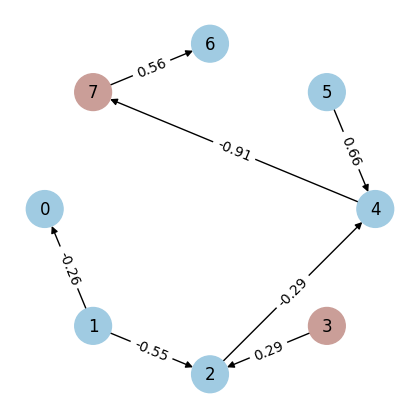

In [19]:
plot_dag(dag, colors=colors)
plt.savefig("dag_ground_truth.pdf")

In [20]:
xai_model = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
explanations = get_all_explanations(xai_model, df)

  0%|          | 0/6 [00:00<?, ?it/s]

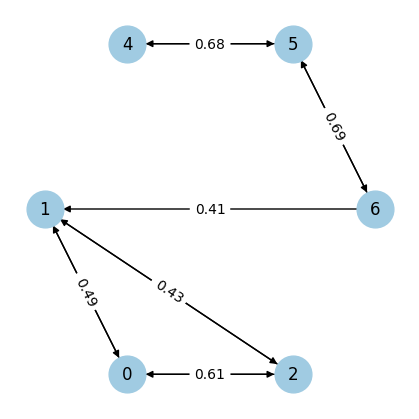

In [34]:
# Plot explanation graph
G_exp = make_dag_from_explanations(explanations, threshold=65)
plot_dag(G_exp)
plt.savefig("dag_predicted.pdf")

In [50]:
G = nx.DiGraph()
edges = []
for target in explanations:
    exp_df = explanations[target].abs().mean()
    edges.extend([{"source": source, "target": target, "weight": weight} for source, weight in exp_df.items()])

# Filter edges by threshold
all_weights = [edge["weight"] for edge in edges]
threshold = np.percentile(all_weights, 65)
edges = [edge for edge in edges if edge["weight"] > threshold]
for edge in edges:
    G.add_edge(edge["source"], edge["target"], weight=edge["weight"])

In [54]:
30*0.35

10.5

In [33]:
nx.graph_edit_distance(
    dag.to_undirected(), 
    make_dag_from_explanations(explanations, threshold=65).to_undirected()
)

5.0

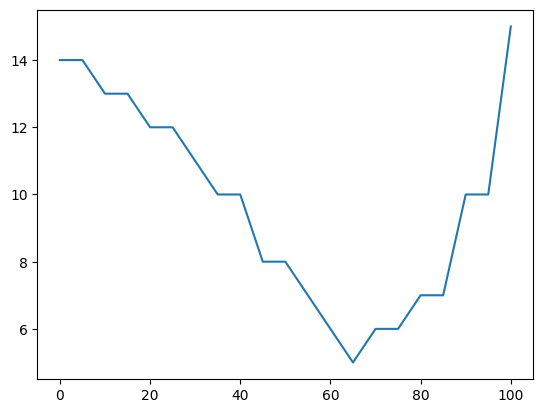

In [28]:
thresholds = list(range(0, 101, 5))
edit_distances = [
    nx.graph_edit_distance(
        dag.to_undirected(), 
        make_dag_from_explanations(explanations, threshold=t).to_undirected()
    )
    for t in thresholds
]
plt.plot(thresholds, edit_distances)

In [36]:
# Generate several DAGs and get explanation graphs
xai_model = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
dags = []
dfs = []
explanations = []
for _ in tqdm(range(50)):
    params = generator._sample_params()
    df, dag = generator._dataset(**params, activations=[identity])
    df.drop(columns=df.columns[-1], inplace=True)  # Drop target column
    df.columns = df.columns.map(lambda x: x.split("_")[1])
    df = df.T.sort_index().T
    dfs.append(df)
    dags.append(dag)
    explanations.append(get_all_explanations(xai_model, df))

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

In [58]:
thresholds = np.arange(0, 100, 5)
all_edit_distances = []
for dag, df, exp_ in tqdm(list(zip(dags, dfs, explanations))):
    edit_distances = [
        nx.graph_edit_distance(
            dag.to_undirected(), 
            make_dag_from_explanations(exp_, threshold=t).to_undirected()
        )
        for t in tqdm(thresholds)
    ]
    all_edit_distances.append(edit_distances)

with open("synthetic_dags_explanations.pkl", "wb") as f:
    pickle.dump((dags, dfs, explanations, all_edit_distances), f)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [63]:
dags, dfs, explanations, all_edit_distances = pickle.load(open("synthetic_dags_explanations.pkl", "rb"))

In [64]:
from mlresearch.utils import set_matplotlib_style
set_matplotlib_style(use_latex=False, font_size=18, **{"font.family":"serif"})

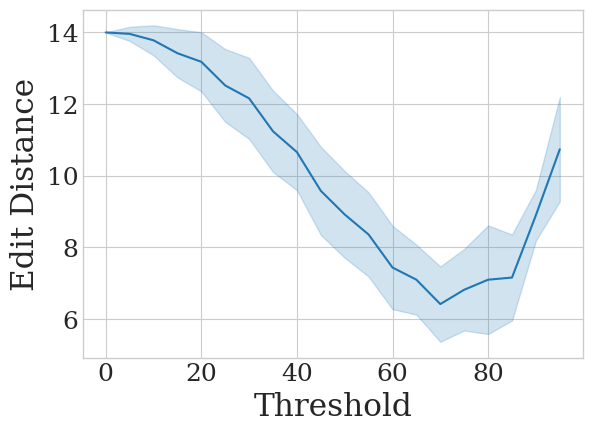

In [66]:
# Plot average edit distances across thresholds (with std shading)
df_distances = pd.DataFrame(all_edit_distances).T
df_distances["Threshold"] = df_distances.index.rename("Threshold") * 5
df_distances = (
    df_distances
    .groupby("Threshold")
    .apply(lambda _df: _df.melt(), include_groups=False)
    .rename(columns={"variable": "DAG", "value": "Edit Distance"})
    .copy()
)
df_distances = df_distances.reset_index().drop(columns="level_1")

sns.lineplot(
    data=df_distances,
    x="Threshold",
    y="Edit Distance",
    errorbar="sd"
)
plt.tight_layout()
plt.savefig("dag_graph_edit_distance.pdf")